![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Análisis de sentimientos y técnicas de NLP

En este taller podrán poner en práctica sus conocimientos sobre las diferentes técnicas para el procesamiento de lenguaje natural. El taller está constituido por 5 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción sentimientos de viajeros en Twitter

En este taller se usará el conjunto de datos de sentimientos sobre distintas aerolíneas de EE.UU. provenientes de Twitter. Cada observación contiene si el sentimiento de los tweets es positivo, neutral o negativo teniendo en cuenta distintas variables como aerolínea y las razones de los sentimientos negativos (como "retraso en el vuelo" o "servicio grosero"). El objetivo es predecir el sentimiento asociado a cada tweet. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/crowdflower/twitter-airline-sentiment).

In [17]:
import warnings
warnings.filterwarnings('ignore')

In [18]:
# Importación de librerías
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

In [19]:
# Lectura de la información de archivo .zip
tweets = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/Tweets.zip', index_col=0)

# Visualización dataset
tweets.head()


,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
tweet_id,,,,,,,,,,,,,,
570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [20]:
# Impresión tamaño del cojunto de datos
tweets.shape

(14640, 14)

In [21]:
list(tweets.columns)

['airline_sentiment',
 'airline_sentiment_confidence',
 'negativereason',
 'negativereason_confidence',
 'airline',
 'airline_sentiment_gold',
 'name',
 'negativereason_gold',
 'retweet_count',
 'text',
 'tweet_coord',
 'tweet_created',
 'tweet_location',
 'user_timezone']

### Análisis descriptivo

In [22]:
# Cuenta de tweets por cada sentimiento
tweets['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

In [23]:
# Cuenta de tweets por cada aerolínea
tweets['airline'].value_counts()

airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

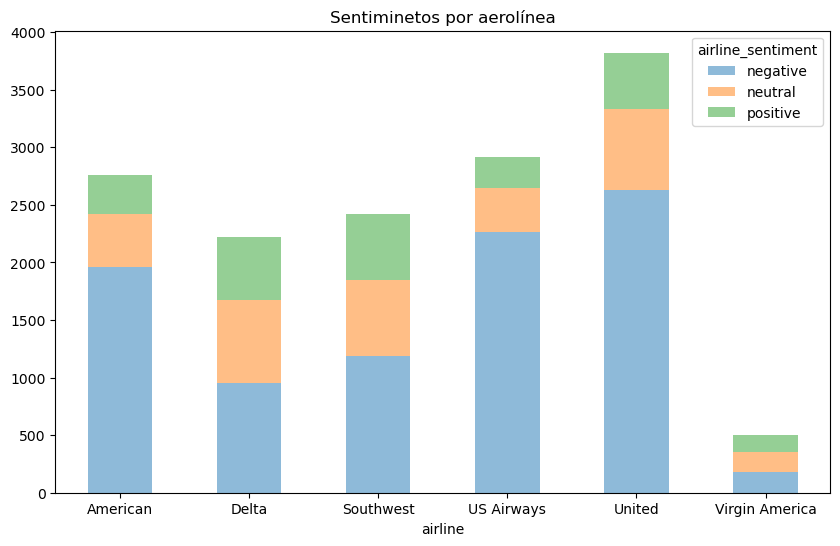

In [24]:
# Plot con cuenta de tweets por cada aerolínea y sentimiento
pd.crosstab(index = tweets["airline"],columns = tweets["airline_sentiment"]).plot(kind='bar',figsize=(10, 6),alpha=0.5,rot=0,stacked=True,title="Sentiminetos por aerolínea")
plt.show()

### Liberias y Variables de interés y predicción

In [25]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from nltk.stem.snowball import SnowballStemmer
from nltk.stem import WordNetLemmatizer
from sklearn.metrics import accuracy_score
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

In [26]:
# Separación de variables predictoras (X) y de variable de interés (y)
X = tweets['text']
y = tweets['airline_sentiment'].map({'negative':-1,'neutral':0,'positive':1})

In [27]:
# Separación de datos en set de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Uso de CountVectorizer

En la celda 1 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [ ]:
# Celda 1
# Vectorización
vectorizer = CountVectorizer(max_features=5000)

# ENTRENAMIENTO
X_train_vectorized = vectorizer.fit_transform(X_train)

# TEST
X_test_vectorized = vectorizer.transform(X_test)

# Modelo
rf_model = RandomForestClassifier(n_estimators=150, random_state=0, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train_vectorized, y_train)

# Resultado
accuracy = rf_model.score(X_test_vectorized, y_test)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7759


### Punto 2 - Eliminación de Stopwords

En la celda 2 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer, **eliminen stopwords** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [ ]:
# Celda 2
# Vectorización
vectorizer = CountVectorizer(max_features=5000, stop_words='english')

# ENTRENAMIENTO
X_train_vectorized = vectorizer.fit_transform(X_train)

# TEST
X_test_vectorized = vectorizer.transform(X_test)

# Modelo
rf_model = RandomForestClassifier(n_estimators=150, random_state=0, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train_vectorized, y_train)

# Resultado
accuracy_sinstopwords = rf_model.score(X_test_vectorized, y_test)
print(f"Accuracy: {accuracy_sinstopwords:.4f}")

Accuracy: 0.7581


### Punto 3 - Lematización con verbos

En la celda 3 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer, **lematizen el texto con verbos** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [ ]:
# Celda 3
# Preparar el lematizador
nltk.download('wordnet')
nltk.download('omw-1.4')
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    # Tokenizamos de forma simple por espacio y lematizamos enfocándonos en verbos ('v')
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(w, pos='v') for w in words]
    return " ".join(lemmatized_words)

# Aplicar lematización a los sets de datos

X_train_lem = X_train.apply(lemmatize_text)
X_test_lem = X_test.apply(lemmatize_text)

# Vectorización (CountVectorizer)

vectorizer = CountVectorizer(max_features=5000)

X_train_vectorized = vectorizer.fit_transform(X_train_lem)
X_test_vectorized = vectorizer.transform(X_test_lem)

# Modelo
rf_model = RandomForestClassifier(n_estimators=150, random_state=0, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train_vectorized, y_train)

# Resultado
y_pred = rf_model.predict(X_test_vectorized)
accuracy_lema = accuracy_score(y_test, y_pred)

print(f"--- DESEMPEÑO CON LEMATIZACIÓN (VERBOS) ---")
print(f"Accuracy en el set de test: {accuracy_lema:.4f}")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\adria\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\adria\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


--- DESEMPEÑO CON LEMATIZACIÓN (VERBOS) ---
Accuracy en el set de test: 0.7798


### Punto 4 - Multiples técnicas

En la celda 4 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer, eliminen stopwords, lematizen el texto con verbos** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [ ]:
# Celda 4
# Preparar el lematizador
nltk.download('wordnet')
nltk.download('omw-1.4')
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    # Tokenizamos de forma simple por espacio y lematizamos enfocándonos en verbos ('v')
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(w, pos='v') for w in words]
    return " ".join(lemmatized_words)

# Aplicar lematización a los sets de datos

X_train_lem = X_train.apply(lemmatize_text)
X_test_lem = X_test.apply(lemmatize_text)

# 3. Vectorización 
vectorizer = CountVectorizer(max_features=5000, stop_words='english')

X_train_vectorized = vectorizer.fit_transform(X_train_lem)
X_test_vectorized = vectorizer.transform(X_test_lem)

# Modelo
rf_model = RandomForestClassifier(n_estimators=150, random_state=0, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train_vectorized, y_train)

# Resultado
y_pred = rf_model.predict(X_test_vectorized)
accuracy_comp = accuracy_score(y_test, y_pred)

print(f"--- DESEMPEÑO CON LEMATIZACIÓN (VERBOS) ---")
print(f"Accuracy en el set de test: {accuracy_comp:.4f}")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\adria\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\adria\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


--- DESEMPEÑO CON LEMATIZACIÓN (VERBOS) ---
Accuracy en el set de test: 0.7603


### Punto 5 - Comparación y análisis de resultados

En la celda 5 comparen los resultados obtenidos de los diferentes modelos (random forest) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

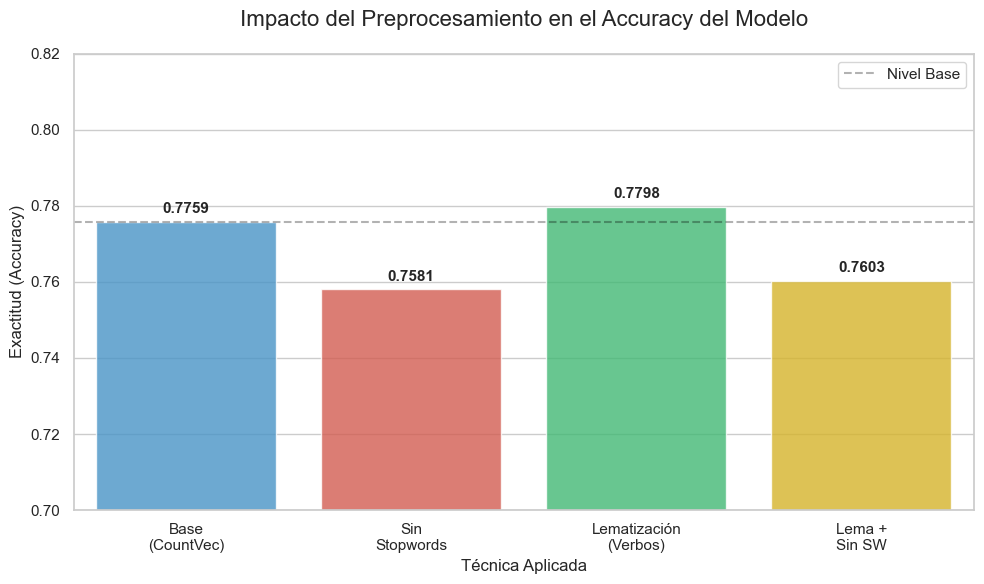

In [ ]:
# Celda 5
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Datos
data = {
    'Técnica': [
        'Base\n(CountVec)', 
        'Sin\nStopwords', 
        'Lematización\n(Verbos)', 
        'Lema +\nSin SW'
    ],
    'Accuracy': [0.7759, 0.7581, 0.7798, 0.7603]
}

df = pd.DataFrame(data)

# Configuración visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f'] # Azul, Rojo, Verde, Amarillo
ax = sns.barplot(x='Técnica', y='Accuracy', data=df, palette=colors, alpha=0.8)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.ylim(0.70, 0.82)


plt.title('Impacto del Preprocesamiento en el Accuracy del Modelo', fontsize=16, pad=20)
plt.ylabel('Exactitud (Accuracy)', fontsize=12)
plt.xlabel('Técnica Aplicada', fontsize=12)

plt.axhline(0.7759, color='black', linestyle='--', alpha=0.3, label='Nivel Base')
plt.legend()

plt.tight_layout()
plt.show()

El proceso de experimentación permitió identificar que la calidad de la predicción de sentimientos en tweets de aerolíneas depende críticamente del equilibrio entre la normalización del lenguaje y la preservación del contexto semántico.

1. Ventajas del mejor modelo: Lematización de verbos (Accuracy: 0.7798)

El modelo basado en lematización de verbos se consolidó como el más efectivo por las siguientes razones:

* Reducción de la dispersión: al estandarizar las distintas formas conjugadas de un verbo (ej. "flying", "flew", "flies") a su raíz morfológica ("fly"), el algoritmo logra agrupar la intención bajo un solo rasgo. Esto permite que el Random Forest encuentre patrones estadísticos más robustos con un vocabulario más compacto.

* Preservación de la carga emocional: a diferencia de otros métodos de limpieza, la lematización no elimina palabras. Al conservar las "stopwords", el modelo mantiene términos de negación críticos (como "not" o "no"), permitiendo distinguir correctamente entre "I am happy" (positivo) y "I am not happy" (negativo).

* Optimización de la señal: Esta técnica actúa como un filtro que elimina variaciones gramaticales irrelevantes, permitiendo que los nodos del árbol de decisión se enfoquen en la raíz de la acción reportada por el usuario.

2. Desventajas del Modelo con Menor Desempeño: Eliminación de Stopwords (Accuracy: 0.7581)

La remoción de palabras vacías resultó en una degradación del desempeño debido a factores inherentes a la naturaleza de los datos:

* Pérdida de contexto gramatical: en textos cortos (tweets), cada palabra tiene un peso significativo. La eliminación de artículos y preposiciones desestructura el mensaje, generando ambigüedad en la interpretación del sentimiento.

* El problema de la negación: Las listas estándar de stopwords suelen eliminar palabras que son vitales en el análisis de sentimientos. Al remover el "not", una queja como "Service was not good" se simplifica a "Service good", induciendo al modelo a un error de clasificación positivo.

* Aumento del suido semántico: Al limpiar "demasiado" el texto, se pierden los conectores que definen la relación entre el pasajero y el problema, haciendo que tweets con sentimientos opuestos terminen teniendo representaciones vectoriales muy similares.

Conclusión 
Se concluye que para este conjunto de datos, la lematización es superior a la limpieza por frecuencia (stopwords), ya que permite simplificar el vocabulario sin sacrificar la lógica lingüística necesaria para detectar la insatisfacción del usuario.